<a href="https://colab.research.google.com/github/mjjaiavinash/avinash-codebooster-2026/blob/main/day_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
print("All Libraries imported successfully")
print("pandas version:", pd.__version__)
print("sqlite3 version:", sqlite3.version)
print("matplotlib version:", plt.matplotlib)


All Libraries imported successfully
pandas version: 2.2.2
sqlite3 version: 2.6.0
matplotlib version: <module 'matplotlib' from '/usr/local/lib/python3.12/dist-packages/matplotlib/__init__.py'>


In [3]:
df = pd.read_csv("/content/drive/MyDrive/15 days intern dataset/student_performance.csv")
df

,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023
5,1006,Meera Joshi,20,Female,Electronics,2,58,66,70,52,72,Pune,2023
6,1007,Kiran Kumar,21,Male,Civil,2,73,69,65,40,85,Bangalore,2023
7,1008,Divya Singh,19,Female,Computer Science,2,88,91,84,93,96,Lucknow,2023
8,1009,Rahul Mishra,20,Male,Mechanical,2,62,71,58,45,68,Varanasi,2023
9,1010,Ananya Das,19,Female,Computer Science,2,95,89,90,97,98,Kolkata,2023


In [4]:
# Create database
conn = sqlite3.connect('student.db')

# Create cursor
cursor = conn.cursor()

# Store dataframe into SQL table
df.to_sql(
    'students',
    conn,
    if_exists='replace',
    index=False
)

30

In [ ]:
conn = sqlite3.connect('student.db') # Re-open the connection
query = "SELECT name ,age FROM students"
df = pd.read_sql(query, conn)
print(df)
conn.close()

              name  age
0     Aarav Sharma   19
1      Priya Patel   20
2      Rohit Verma   19
3      Sneha Reddy   20
4       Arjun Nair   19
5      Meera Joshi   20
6      Kiran Kumar   21
7      Divya Singh   19
8     Rahul Mishra   20
9       Ananya Das   19
10     Vikram Iyer   20
11     Pooja Gupta   19
12      Suresh Rao   21
13   Kavya Nambiar   20
14     Ajay Tiwari   19
15    Ritu Agarwal   20
16    Manoj Pandey   21
17  Swati Kulkarni   19
18  Deepak Chauhan   20
19    Nisha Kapoor   19
20   Harish Pillai   20
21     Tanvi Mehta   19
22    Sanjay Dubey   21
23   Preeti Saxena   20
24       Amit Bose   19
25      Rekha Nair   20
26   Gaurav Shukla   21
27   Sunita Pillai   19
28      Nitin Jain   20
29  Akanksha Yadav   19


In [ ]:
conn = sqlite3.connect('student.db')
cursor = conn.cursor
query = "SELECT student_id ,name FROM students LIMIT 5"
df = pd.read_sql(query, conn)
print(df)
conn.close()


   student_id          name
0        1001  Aarav Sharma
1        1002   Priya Patel
2        1003   Rohit Verma
3        1004   Sneha Reddy
4        1005    Arjun Nair


In [ ]:
conn = sqlite3.connect('student.db')

cursor = conn.cursor()

query = """
SELECT name, department, math_score
FROM students
WHERE math_score >= 90
ORDER BY math_score DESC
"""

df = pd.read_sql(query, conn)

print(df)

conn.close()

             name        department  math_score
0      Ananya Das  Computer Science          95
1     Tanvi Mehta  Computer Science          93
2      Arjun Nair  Computer Science          92
3  Akanksha Yadav  Computer Science          91
4  Swati Kulkarni  Computer Science          90


In [ ]:
# Top 5 performers with math_score >=90

conn = sqlite3.connect('student.db')

cursor = conn.cursor()

query = """
SELECT name, department, math_score
FROM students
WHERE math_score >= 90
ORDER BY math_score DESC
"""

df = pd.read_sql(query, conn)

print(df)


             name        department  math_score
0      Ananya Das  Computer Science          95
1     Tanvi Mehta  Computer Science          93
2      Arjun Nair  Computer Science          92
3  Akanksha Yadav  Computer Science          91
4  Swati Kulkarni  Computer Science          90


In [ ]:
# AttendancePercentage > 90 Exluding Civil

query = """
SELECT name, department, attendance_percentage
FROM students
WHERE attendance_percentage > 90
AND department != 'Civil'
order by attendance_percentage desc
"""
df = pd.read_sql(query, conn)

print(df)

             name        department  attendance_percentage
0      Ananya Das  Computer Science                     98
1     Tanvi Mehta  Computer Science                     97
2     Divya Singh  Computer Science                     96
3     Sneha Reddy        Mechanical                     95
4  Akanksha Yadav  Computer Science                     95
5  Swati Kulkarni  Computer Science                     94
6    Ritu Agarwal       Electronics                     93
7    Aarav Sharma  Computer Science                     92
8   Kavya Nambiar        Mechanical                     91
9       Amit Bose  Computer Science                     91


In [ ]:
query = """
select department,
count(*) AS num_students,
ROUND(AVG(math_score),2) AS avg_math_score,
ROUND(AVG(science_score),2) AS avg_science_score,
ROUND(AVG(programming_score),2) AS avg_programming_score,
ROUND(AVG(attendance_percentage),2) AS avg_attendance_percentage
from students
group by department
order by avg_math_score desc
"""
df = pd.read_sql(query, conn)
print(df)

         department  num_students  avg_math_score  avg_science_score  \
0  Computer Science            13           85.62              84.46   
1        Mechanical             6           71.00              76.50   
2       Electronics             6           71.00              74.17   
3             Civil             5           63.40              66.60   

   avg_programming_score  avg_attendance_percentage  
0                  89.23                      90.69  
1                  49.33                      83.50  
2                  61.50                      80.33  
3                  40.60                      74.60  


In [ ]:
query = """
SELECT
    department,
    COUNT(*) AS total_students,
    ROUND(AVG(math_score), 2) AS avg_math

FROM students

GROUP BY department

HAVING AVG(math_score) > 70
order by avg_math desc
"""

df = pd.read_sql(query, conn)

print(df)

         department  total_students  avg_math
0  Computer Science              13     85.62
1        Mechanical               6     71.00
2       Electronics               6     71.00


In [ ]:
query = """
select
gender,
count(*) AS num_students,
ROUND(AVG(math_score), 2) AS avg_math,
ROUND(AVG(programming_score), 2) AS avg_programming,
ROUND(AVG(attendance_percentage), 2) AS avg_attendance
from students
group by gender
"""
df = pd.read_sql(query, conn)

print(df)


   gender  num_students  avg_math  avg_programming  avg_attendance
0  Female            15     78.47             70.2           88.53
1    Male            15     73.67             65.0           80.47


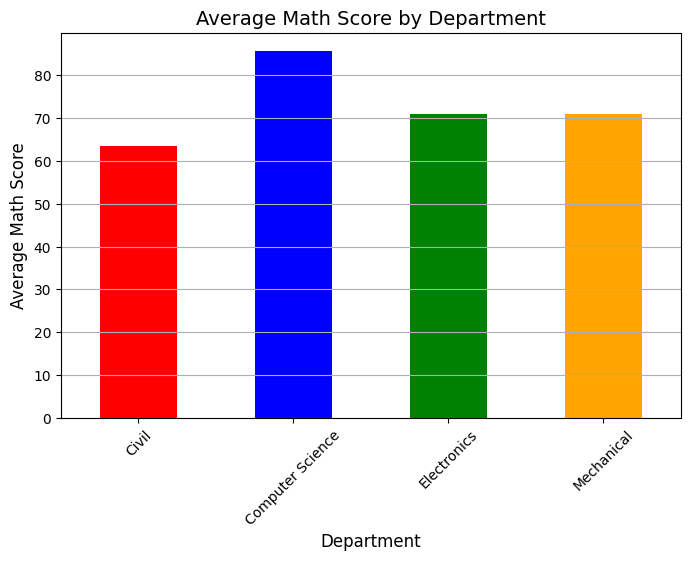

In [ ]:
avg_math = df.groupby('department')['math_score'].mean()

plt.figure(figsize=(8,5))

avg_math.plot(
    kind='bar',
    color=['red', 'blue', 'green', 'orange']
)

plt.title("Average Math Score by Department", fontsize=14)
plt.xlabel("Department", fontsize=12)
plt.ylabel("Average Math Score", fontsize=12)

plt.xticks(rotation=45)

plt.grid(axis='y')

plt.show()

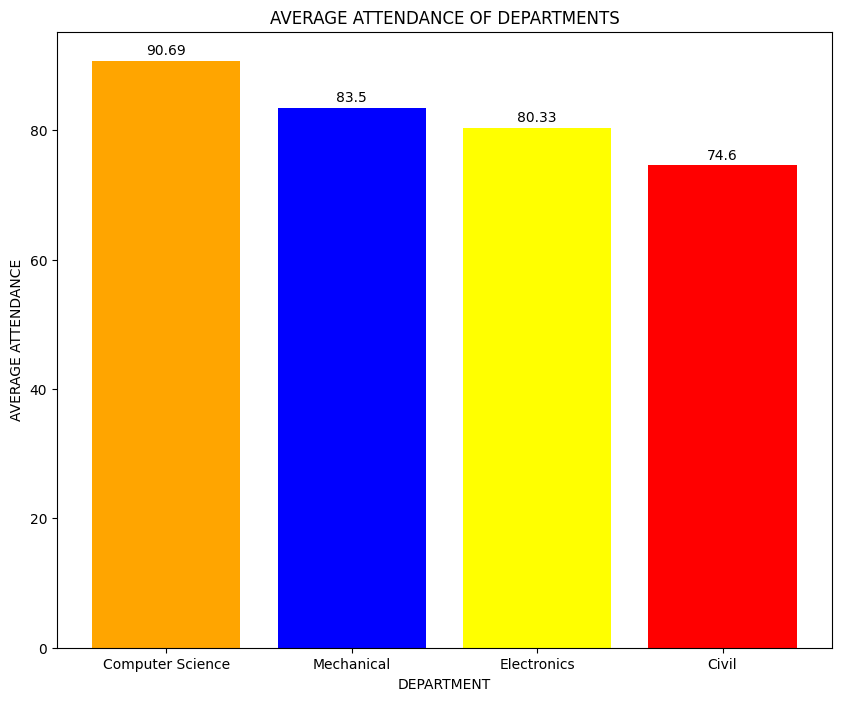

In [ ]:
fig , ax = plt.subplots(figsize=(10,8))
plt.title("AVERAGE ATTENDANCE OF DEPARTMENTS")
plt.xlabel("DEPARTMENT")
plt.ylabel("AVERAGE ATTENDANCE")
bars = plt.bar(avg_attendance.index, avg_attendance.values, color = ['orange','blue','yellow','red'])

# Add the percentage values on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, round(yval, 2), ha='center', va='bottom') # +0.5 for a small offset above the bar

plt.show()

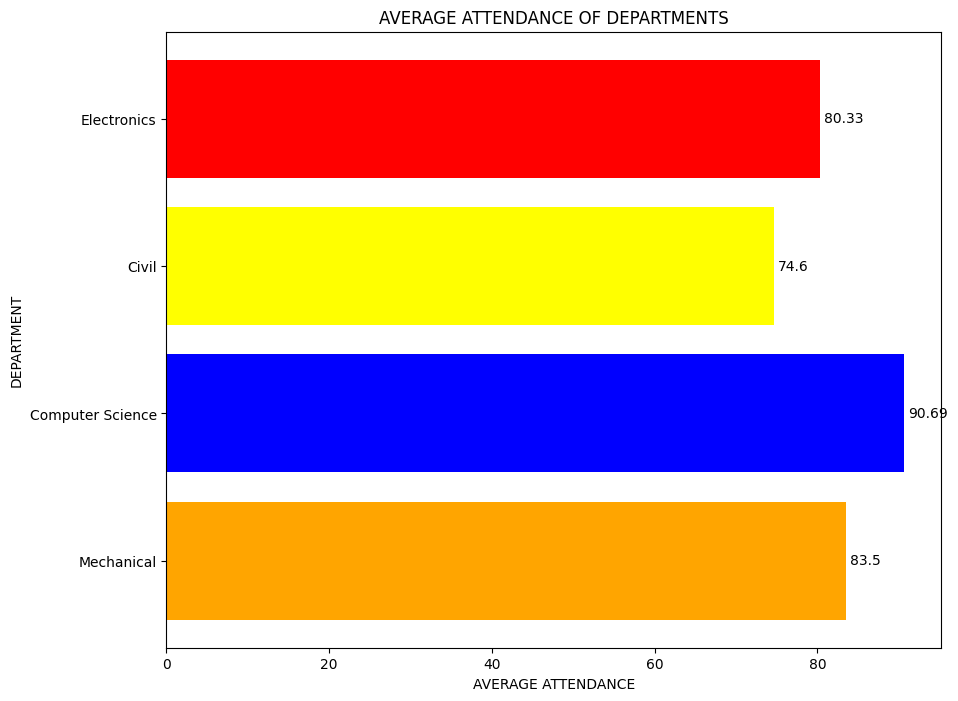

In [ ]:
fig, ax = plt.subplots(figsize=(10,8))

plt.title("AVERAGE ATTENDANCE OF DEPARTMENTS")

# Swapped labels (for horizontal bar chart)
plt.xlabel("AVERAGE ATTENDANCE")
plt.ylabel("DEPARTMENT")

bars = plt.barh( # Changed to barh for horizontal bars
    data['department'], # Used 'data' dataframe
    data['avg_attendance'], # Used 'data' dataframe
    color=['orange', 'blue', 'yellow', 'red']
)

# Add average attendance values on top of bars
for bar in bars:
    attendance_value = bar.get_width() # For horizontal bars, width is the value

    plt.text(
        attendance_value + 0.5, # Position x: at the end of the bar + offset
        bar.get_y() + bar.get_height()/2, # Position y: at the center of the bar
        round(attendance_value, 2),
        ha='left', # horizontal alignment: left of the text, so it's after the bar
        va='center' # vertical alignment: center of the bar
    )

plt.show()

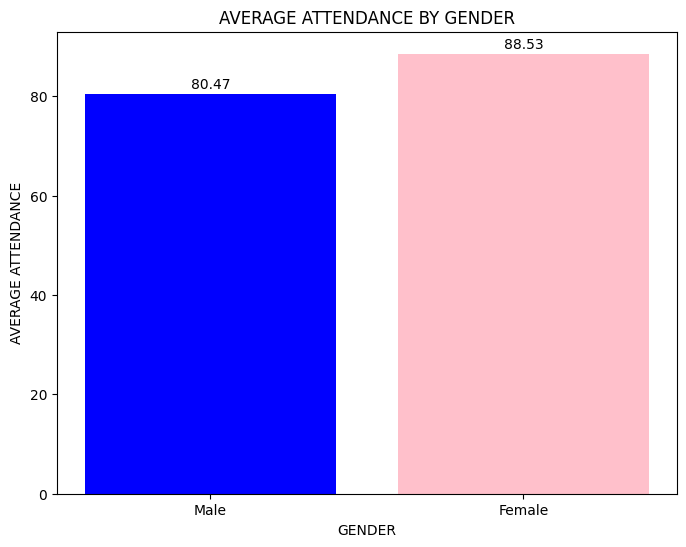

In [ ]:
data = data.set_index('gender').reindex(['Male', 'Female']).reset_index()

fig, ax = plt.subplots(figsize=(8,6))

plt.title("AVERAGE ATTENDANCE BY GENDER")
plt.xlabel("GENDER")
plt.ylabel("AVERAGE ATTENDANCE")

bars = plt.bar(
    data['gender'],
    data['avg_attendance'],
    color=['blue', 'pink']
)

# Add attendance values on bars
for bar in bars:
    attendance_value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        attendance_value + 0.5,
        round(attendance_value, 2),
        ha='center',
        va='bottom'
    )

plt.show()

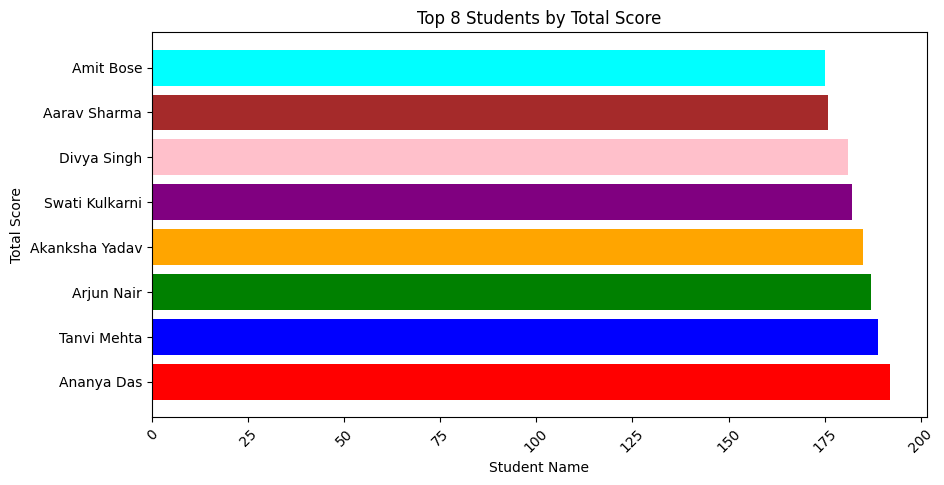

In [ ]:
import matplotlib.pyplot as plt

# Create total score column
df['total_score'] = (
    df['math_score'] +
    df['programming_score']
)

# Get top 8 students
top_students = df.nlargest(8, 'total_score')

colors = ['red', 'blue', 'green', 'orange', 'purple', 'pink', 'brown', 'cyan']

# -----------------------------
# Graph 1 : Total Score
# -----------------------------
plt.figure(figsize=(10,5))


plt.xlabel('Student Name')
plt.ylabel('Total Score')

plt.title('Top 8 Students by Total Score')

plt.xticks(rotation=45)

# plt.grid(axis='x', linestyle='--')
plt.barh(
    top_students['name'],
    top_students['total_score'],
    color=colors
)

# for i, value in enumerate(top_students['total_score']):
#     plt.text(i, value + 1, f'{value:.1f}', ha='center')

# plt.tight_layout()
plt.show()

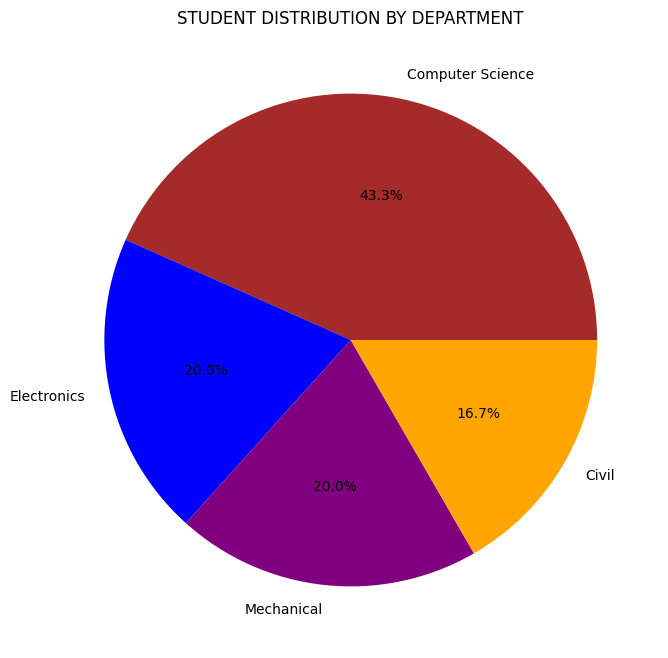

In [ ]:
# Count students department-wise

dept_count = df['department'].value_counts()

# Create pie chart

fig, ax = plt.subplots(figsize=(8,8))

plt.pie(
    dept_count.values,
    labels=dept_count.index,
    autopct='%1.1f%%',
    colors=['brown', 'blue', 'purple', 'orange']
)

plt.title("STUDENT DISTRIBUTION BY DEPARTMENT")

plt.show()

In [ ]:

conn = sqlite3.connect('student.db')

query = """
SELECT
    ROUND(AVG(programming_score), 2) AS avg_programming_score
FROM students
WHERE gender = 'Female'
"""

df = pd.read_sql(query, conn)

print(df)

conn.close()

   avg_programming_score
0                   70.2


In [ ]:
conn = sqlite3.connect('student.db')

query = """
SELECT
    department,
    ROUND(AVG(attendance_percentage), 2) AS avg_attendance_percentage

FROM students

GROUP BY department

HAVING AVG(attendance_percentage) > 85
"""

df = pd.read_sql(query, conn)

print(df)

conn.close()

         department  avg_attendance_percentage
0  Computer Science                      90.69


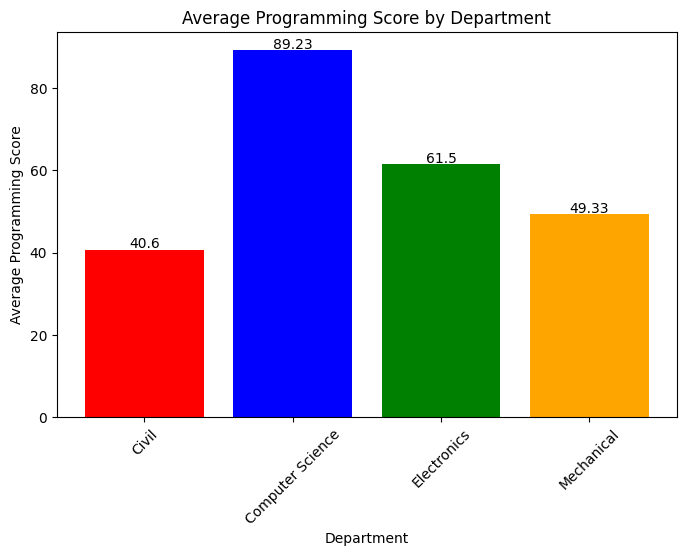

In [6]:
avg_programming = df.groupby('department')['programming_score'].mean()

fig, ax = plt.subplots(figsize=(8,5))

bars = plt.bar(
    avg_programming.index,
    avg_programming.values,
    color=['red', 'blue', 'green', 'orange']
)

plt.title("Average Programming Score by Department")
plt.xlabel("Department")
plt.ylabel("Average Programming Score")

plt.xticks(rotation=45)

for bar in bars:
    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.5,
        round(value, 2),
        ha='center'
    )


plt.show()